# Classical Baselines — DEAP LOSO, Final Run

Sanjeev Veeramani (100004303) — Case Study 2 — Report 2 Part 2

Covers two of the five baseline models in Prof. Vu's brief: **SVM** and **Random Forest** on handcrafted features, trained on DEAP under LOSO. The remaining three (CNN, LSTM, BiLSTM on raw segments) are in `03_baselines_deep_colab.ipynb`.

## Configuration source

Feature subset and reduction method were selected empirically in `02b_experiment_two_stage_colab.ipynb`, which screened 10 configurations across 3 feature subsets, 3 reduction methods and 4 classifiers over 15 folds on both binary tasks:

| Rank | Config | Dim | Val bal | Aro bal |
|---|---|---|---|---|
| 1 | DE+PSD + SelectKBest(100) + RF | 320 | 53.74 | 51.24 |
| 2 | DE+PSD + RF | 320 | 53.29 | 51.08 |
| 3 | All9 + PCA(200) + RF | 3628 | 52.31 | 50.69 |

All four leading configurations used DE+PSD only. Univariate selection rates on the full 9-feature space were DE 18.12%, PSD 13.12%, PLV 1.25% — PLV contributes 68% of the dimensions but almost none of the discriminative signal.

## Substitution

**LinearSVC in place of RBF-SVM.** RBF-SVM is O(N²)–O(N³) in training samples. At 147,560 training samples per fold × 32 folds × 3 tasks, estimated runtime exceeds 90 hours. RBF figures are cited from published work rather than reproduced. Recorded in Table 7 of Report 2 Part 1.

## Label provenance

Labels were rebuilt from the official `participant_ratings.xls`. The Kaggle DEAP mirror's valence and arousal columns were found corrupted — minimum 0.00 on a 1–9 SAM scale, means 3.47 and 3.73 against expected 5.25 and 5.16, with 6.3% and 5.2% of values clipped at the floor. Dominance and liking in the same files matched the official ratings to 0.0000 absolute difference, confirming selective corruption of two columns rather than a whole-file fault. Trial alignment used `Experiment_id` ordering, verified against the intact dominance column.

Post-correction distribution: valence 55.3/44.7, arousal 57.6/42.4. Minority-class trials per subject rose from 2–6 to 10–20 (median 17).

## Section 0 — Environment

Mounts Drive and reports available cores and RAM. Core count determines fold-level parallelism in Section 3; the run is CPU-bound, so GPU allocation is irrelevant here.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
DATA_DIR = Path('/content/drive/MyDrive/case_study_2/processed')
print(f'DATA_DIR exists: {DATA_DIR.exists()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR exists: True


In [2]:
import os, time, gc, csv, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_recall_fscore_support, confusion_matrix,
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 9

N_CORES = os.cpu_count()
try:
    import psutil
    vm = psutil.virtual_memory()
    ram_total, ram_avail = vm.total / 1e9, vm.available / 1e9
except Exception:
    ram_total = ram_avail = float('nan')

print(f'CPU cores:     {N_CORES}')
print(f'RAM total:     {ram_total:.1f} GB')
print(f'RAM available: {ram_avail:.1f} GB')
print(f'sklearn:       {__import__("sklearn").__version__}')

CPU cores:     12
RAM total:     56.9 GB
RAM available: 55.1 GB
sklearn:       1.6.1


## Section 1 — Configuration

`SUBSAMPLE = None` uses all 152,320 segments; the experiment notebook used every 5th segment for speed. Chance levels differ by task — 50% for the two binary tasks, 33.3% for 3-class — and are used both for the significance tests in Section 7 and the reference lines on the per-subject plots in Section 8.

In [3]:
DATASET     = 'deap'
FEATURES    = ['DE', 'PSD']
LABEL_TYPES = ['valence', 'arousal', '3class']
SUBSAMPLE   = None                # None = all 152,320 segments
SEED        = 42
K_SELECT    = 100

REPORT_TAG  = 'R2P2_final'
LOG_PATH    = DATA_DIR / 'results_log.csv'
FOLD_PATH   = DATA_DIR / 'results_per_fold.csv'

CHANCE = {'valence': 50.0, 'arousal': 50.0, '3class': 100 / 3}
CLASS_NAMES = {'valence': ['Low', 'High'],
               'arousal': ['Low', 'High'],
               '3class':  ['Neg', 'Neu', 'Pos']}

N_JOBS = max(1, N_CORES)          # folds parallel, models single-threaded

print(f'Features:  {FEATURES}')
print(f'Tasks:     {LABEL_TYPES}')
print(f'Subsample: {SUBSAMPLE}')
print(f'Parallel folds: {N_JOBS}')
print(f'Chance: {CHANCE}')

Features:  ['DE', 'PSD']
Tasks:     ['valence', 'arousal', '3class']
Subsample: None
Parallel folds: 12
Chance: {'valence': 50.0, 'arousal': 50.0, '3class': 33.333333333333336}


## Section 2 — Load features and labels

Loads the per-subject z-scored DE and PSD files produced by the feature engineering notebook and concatenates them to 320 dimensions (32 channels × 5 bands × 2 features). Asserts that feature, label and subject-ID arrays have matching lengths, and that no NaN or Inf survived feature extraction — a failed assertion here means the upstream extraction needs rerunning rather than the training.

The printed majority-class percentage is the accuracy a degenerate classifier would achieve by always predicting the dominant class. Comparing it against the accuracy in Section 6 shows whether the model learned anything beyond class priors.

In [4]:
subject_ids_full = np.load(DATA_DIR / f'{DATASET}_subject_ids.npy')
keep = (np.arange(0, len(subject_ids_full), SUBSAMPLE)
        if SUBSAMPLE else np.arange(len(subject_ids_full)))
subject_ids = subject_ids_full[keep]

parts = []
for name in FEATURES:
    p = DATA_DIR / f'X_{DATASET}_{name}_zscored.npy'
    arr = np.load(p, mmap_mode='r')
    sub = np.asarray(arr[keep]).astype(np.float32)
    print(f'  {name:9s} {str(sub.shape):18s} {sub.nbytes/1e6:7.1f} MB')
    parts.append(sub)
X = np.concatenate(parts, axis=1)
del parts; gc.collect()
print(f'\nX: {X.shape}   {X.nbytes/1e6:.1f} MB')

LABELS = {}
for task in LABEL_TYPES:
    y_full = np.load(DATA_DIR / f'y_{DATASET}_{task}.npy')
    LABELS[task] = y_full[keep]
    u, c = np.unique(LABELS[task], return_counts=True)
    print(f'  {task:9s} {dict(zip(u.tolist(), c.tolist()))}   '
          f'majority = {c.max()/c.sum()*100:.2f}%   chance = {CHANCE[task]:.2f}%')

N_SUBJECTS = len(np.unique(subject_ids))
print(f'\nSubjects: {N_SUBJECTS}   segments: {X.shape[0]}')
for t, y in LABELS.items():
    assert len(y) == X.shape[0] == len(subject_ids), f'length mismatch on {t}'
assert not np.isnan(X).any() and not np.isinf(X).any(), 'NaN/Inf in X'
print('Integrity: PASS')

  DE        (152320, 160)         97.5 MB
  PSD       (152320, 160)         97.5 MB

X: (152320, 320)   195.0 MB
  valence   {0: 68068, 1: 84252}   majority = 55.31%   chance = 50.00%
  arousal   {0: 64617, 1: 87703}   majority = 57.58%   chance = 50.00%
  3class    {0: 56168, 1: 26299, 2: 69853}   majority = 45.86%   chance = 33.33%

Subjects: 32   segments: 152320
Integrity: PASS


## Section 3 — LOSO runner

One fold per DEAP subject: fit on 31 subjects (147,560 segments), predict the held-out subject (4,760 segments), repeat 32 times.

**Metrics per fold.** Accuracy, balanced accuracy, precision, recall and F1 — the last three in both macro and weighted form. Macro weights each class equally and so exposes poor minority-class performance; weighted follows class frequency and tracks accuracy more closely. Both are recorded because DEAP's per-subject class distributions are uneven even after the label correction.

**Significance.** Per-fold balanced accuracy is tested against the task's chance level with a one-sample t-test, one-sided since only improvement above chance is of interest. This is what distinguishes a genuine effect from a mean that merely looks above 50%.

**Parallelism.** Folds are distributed across cores with `n_jobs=1` inside each model; Random Forest's internal tree-level parallelism scales sublinearly, so fold-level parallelism is the faster arrangement. `threadpool_limits(1)` in each worker prevents BLAS from spawning its own threads, which would oversubscribe the cores and make the parallel version slower than sequential. Pipelines are built from plain-data specs rather than closures so they pickle cleanly to worker processes.

In [5]:
def build_pipeline(spec):
    steps = []
    if spec.get('select'):
        steps.append(('sel', SelectKBest(f_classif, k=spec['select'])))
    clf = spec['clf']
    if clf == 'rf':
        steps.append(('clf', RandomForestClassifier(
            n_estimators=100, min_samples_leaf=5, max_features='sqrt',
            class_weight='balanced', n_jobs=1, random_state=SEED)))
    elif clf == 'linsvc':
        steps.append(('clf', LinearSVC(
            C=1.0, dual='auto', max_iter=5000,
            class_weight='balanced', random_state=SEED)))
    else:
        raise ValueError(f'unknown clf: {clf}')
    return Pipeline(steps)


def _one_fold(X, y, sids, sid, spec):
    test_mask = sids == sid
    y_te = y[test_mask]
    with threadpool_limits(limits=1):
        pipe = build_pipeline(spec)
        t0 = time.time()
        pipe.fit(X[~test_mask], y[~test_mask])
        fit_s = time.time() - t0
        pred = pipe.predict(X[test_mask])

    p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(
        y_te, pred, average='macro', zero_division=0)
    p_wgt, r_wgt, f_wgt, _ = precision_recall_fscore_support(
        y_te, pred, average='weighted', zero_division=0)

    return {
        'sid': int(sid),
        'n_test': int(test_mask.sum()),
        'acc':      accuracy_score(y_te, pred) * 100,
        'bal_acc':  balanced_accuracy_score(y_te, pred) * 100,
        'prec_macro': p_mac * 100, 'rec_macro': r_mac * 100, 'f1_macro': f_mac * 100,
        'prec_wgt':   p_wgt * 100, 'rec_wgt':   r_wgt * 100, 'f1_wgt':   f_wgt * 100,
        'fit_s': fit_s,
        'pred': pred, 'true': y_te,
    }


def run_loso(model_name, spec, task, n_jobs=N_JOBS):
    y = LABELS[task]
    subjects = np.unique(subject_ids)
    print(f'  {len(subjects)} folds, {n_jobs} parallel ...', flush=True)

    t0 = time.time()
    folds = Parallel(n_jobs=n_jobs, backend='loky', verbose=1)(
        delayed(_one_fold)(X, y, subject_ids, sid, spec) for sid in subjects
    )
    wall_min = (time.time() - t0) / 60

    per = {k: np.array([f[k] for f in folds])
           for k in ['acc','bal_acc','prec_macro','rec_macro','f1_macro',
                     'prec_wgt','rec_wgt','f1_wgt','fit_s']}

    bal = per['bal_acc']
    t_stat, p_two = stats.ttest_1samp(bal, CHANCE[task])
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    preds_cat = np.concatenate([f['pred'] for f in folds])
    pu, pc = np.unique(preds_cat, return_counts=True)

    res = {
        'model': model_name, 'task': task,
        'n_folds': len(subjects), 'dim_in': X.shape[1],
        'wall_min': wall_min,
        'pred_dist': {int(a): int(b) for a, b in zip(pu, pc)},
        'frac_majority_pred': float(pc.max() / pc.sum()),
        't_stat': float(t_stat), 'p_one_sided': float(p_one),
        'chance': CHANCE[task],
        'per_fold': folds,
    }
    for k, v in per.items():
        res[k] = float(v.mean())
        res[k + '_std'] = float(v.std())
    res['bal_acc_sem'] = float(bal.std() / np.sqrt(len(bal)))

    sig = 'ABOVE CHANCE' if p_one < 0.05 else 'not significant'
    print(f'  acc={res["acc"]:5.2f} ±{res["acc_std"]:4.2f}   '
          f'bal={res["bal_acc"]:5.2f} ±{res["bal_acc_std"]:4.2f}   '
          f'P={res["prec_macro"]:5.2f}  R={res["rec_macro"]:5.2f}  '
          f'F1={res["f1_macro"]:5.2f}')
    print(f'  t={t_stat:5.2f}  p={p_one:.4f}  [{sig}]   wall={wall_min:.1f} min\n')
    return res

print('Runner ready.')

Runner ready.


## Section 4 — Model specifications

Three configurations, nine runs in total (3 models × 3 label types), each a full 32-fold LOSO.

Both Random Forest variants are included because the experiment separated them by only 0.45 pp on valence — below what 15 folds could resolve. Running both on the complete dataset settles whether univariate feature selection is worth the extra pipeline stage.

`class_weight='balanced'` is set on every model: without it, the residual class imbalance in DEAP drives predictions toward the dominant class and inflates raw accuracy.

In [6]:
MODELS = [
    ('RF_sel',   {'select': K_SELECT, 'clf': 'rf'},     'RandomForest + SelectKBest(100)'),
    ('RF_plain', {'select': None,     'clf': 'rf'},     'RandomForest, 320 dims'),
    ('LinearSVC',{'select': None,     'clf': 'linsvc'}, 'LinearSVC'),
]

for name, spec, label in MODELS:
    print(f'  {name:10s} {label}')

total_runs = len(MODELS) * len(LABEL_TYPES)
print(f'\n{len(MODELS)} models x {len(LABEL_TYPES)} tasks = {total_runs} runs '
      f'x {N_SUBJECTS} folds')
print('Estimated wall time: 2.5 - 3.5 h')

  RF_sel     RandomForest + SelectKBest(100)
  RF_plain   RandomForest, 320 dims
  LinearSVC  LinearSVC

3 models x 3 tasks = 9 runs x 32 folds
Estimated wall time: 2.5 - 3.5 h


## Section 5 — Execute

Runs all nine model × task combinations. Each completed run is appended to `results_log.csv` (one summary row) and `results_per_fold.csv` (32 rows) on Drive before the next begins, so a dropped Colab session costs at most the run in progress rather than the whole sitting.

Progress prints as `[4/9] RF_plain — valence (elapsed 47.2 min)`.

In [7]:
import pandas as pd

for path, tag in [(LOG_PATH, 'results_log'), (FOLD_PATH, 'results_per_fold')]:
    if path.exists():
        new_name = path.parent / f'{tag}_OLD_SCHEMA.csv'
        path.rename(new_name)
        print(f'renamed  {path.name}  ->  {new_name.name}')
    else:
        print(f'{path.name} not present')

print('\nfresh logs will be created with the current schema')

results_log.csv not present
results_per_fold.csv not present

fresh logs will be created with the current schema


In [8]:
SUMMARY_FIELDS = [
    'run_id','date','report','dataset','protocol','model','features','dim_in',
    'label_type','n_folds','n_segments',
    'acc','acc_std','bal_acc','bal_acc_std','bal_acc_sem',
    'prec_macro','rec_macro','f1_macro',
    'prec_wgt','rec_wgt','f1_wgt',
    'chance','t_stat','p_one_sided','significant',
    'frac_majority_pred','wall_min','notes',
]

FOLD_FIELDS = ['run_id','model','task','sid','n_test','acc','bal_acc',
               'prec_macro','rec_macro','f1_macro','fit_s']

def append_csv(path, fields, row):
    new = not path.exists() or path.stat().st_size < 5
    with open(path, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fields)
        if new:
            w.writeheader()
        w.writerow(row)

def next_run_id(path):
    if not path.exists() or path.stat().st_size < 5:
        return 1
    with open(path, newline='') as f:
        ids = [int(r['run_id']) for r in csv.DictReader(f) if r.get('run_id')]
    return max(ids) + 1 if ids else 1

def log_run(res, model_name, task, label):
    rid = next_run_id(LOG_PATH)
    append_csv(LOG_PATH, SUMMARY_FIELDS, {
        'run_id': rid,
        'date': datetime.now().strftime('%Y-%m-%d %H:%M'),
        'report': REPORT_TAG, 'dataset': DATASET, 'protocol': 'LOSO',
        'model': model_name, 'features': '+'.join(FEATURES),
        'dim_in': res['dim_in'], 'label_type': task,
        'n_folds': res['n_folds'], 'n_segments': X.shape[0],
        'acc': round(res['acc'], 2), 'acc_std': round(res['acc_std'], 2),
        'bal_acc': round(res['bal_acc'], 2),
        'bal_acc_std': round(res['bal_acc_std'], 2),
        'bal_acc_sem': round(res['bal_acc_sem'], 3),
        'prec_macro': round(res['prec_macro'], 2),
        'rec_macro': round(res['rec_macro'], 2),
        'f1_macro': round(res['f1_macro'], 2),
        'prec_wgt': round(res['prec_wgt'], 2),
        'rec_wgt': round(res['rec_wgt'], 2),
        'f1_wgt': round(res['f1_wgt'], 2),
        'chance': round(res['chance'], 2),
        't_stat': round(res['t_stat'], 3),
        'p_one_sided': round(res['p_one_sided'], 5),
        'significant': 'yes' if res['p_one_sided'] < 0.05 else 'no',
        'frac_majority_pred': round(res['frac_majority_pred'], 4),
        'wall_min': round(res['wall_min'], 1),
        'notes': f'SUBSAMPLE={SUBSAMPLE}, class_weight=balanced, {label}',
    })
    for f in res['per_fold']:
        append_csv(FOLD_PATH, FOLD_FIELDS,
                   {'run_id': rid, 'model': model_name, 'task': task,
                    'sid': f['sid'], 'n_test': f['n_test'],
                    'acc': round(f['acc'], 3), 'bal_acc': round(f['bal_acc'], 3),
                    'prec_macro': round(f['prec_macro'], 3),
                    'rec_macro': round(f['rec_macro'], 3),
                    'f1_macro': round(f['f1_macro'], 3),
                    'fit_s': round(f['fit_s'], 1)})
    return rid

print('Helpers defined.')

Helpers defined.


In [9]:
PRED_DIR = DATA_DIR / 'preds'
PRED_DIR.mkdir(exist_ok=True)

# check saved predictions directly, not the log
completed = {(m, t) for m, _, _ in MODELS for t in LABEL_TYPES
             if (PRED_DIR / f'{m}_{t}.npz').exists()}
print(f'Found saved predictions: {sorted(completed) or "none"}')

logged = set()
if LOG_PATH.exists() and LOG_PATH.stat().st_size > 5:
    _l = pd.read_csv(LOG_PATH)
    _l = _l[_l['report'] == REPORT_TAG]
    logged = set(zip(_l['model'], _l['label_type']))
print(f'Already logged to CSV:   {sorted(logged) or "none"}\n')

results = {}
t_start = time.time()
run_no = 0

for model_name, spec, label in MODELS:
    for task in LABEL_TYPES:
        run_no += 1

        if (model_name, task) in completed:
            d = np.load(PRED_DIR / f'{model_name}_{task}.npz', allow_pickle=True)
            res = d['res'].item()
            results[(model_name, task)] = res
            if (model_name, task) not in logged:
                log_run(res, model_name, task, label)
                print(f'[{run_no}/{total_runs}] {model_name} — {task}  RESUMED + logged')
            else:
                print(f'[{run_no}/{total_runs}] {model_name} — {task}  RESUMED')
            continue

        elapsed = (time.time() - t_start) / 60
        print(f'{"="*72}')
        print(f'  [{run_no}/{total_runs}]  {model_name} — {task}   (elapsed {elapsed:.1f} min)')
        print(f'{"="*72}')

        res = run_loso(model_name, spec, task)
        results[(model_name, task)] = res

        np.savez_compressed(PRED_DIR / f'{model_name}_{task}.npz',
                            res=np.array(res, dtype=object))
        log_run(res, model_name, task, label)
        gc.collect()

print(f'{"="*72}')
print(f'COMPLETE — {(time.time()-t_start)/60:.1f} min')
print(f'{"="*72}')

Found saved predictions: [('RF_sel', 'valence')]
Already logged to CSV:   none

[1/9] RF_sel — valence  RESUMED + logged
  [2/9]  RF_sel — arousal   (elapsed 0.0 min)
  32 folds, 12 parallel ...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  32 out of  32 | elapsed: 23.9min finished


  acc=54.15 ±9.50   bal=50.76 ±2.46   P=51.00  R=50.76  F1=46.61
  t= 1.72  p=0.0477  [ABOVE CHANCE]   wall=23.9 min

  [3/9]  RF_sel — 3class   (elapsed 23.9 min)
  32 folds, 12 parallel ...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  32 out of  32 | elapsed: 24.8min finished


  acc=44.56 ±6.59   bal=36.08 ±5.49   P=35.58  R=35.50  F1=31.97
  t= 2.79  p=0.0045  [ABOVE CHANCE]   wall=24.8 min

  [4/9]  RF_plain — valence   (elapsed 48.7 min)
  32 folds, 12 parallel ...


...

  acc=53.58 ±7.82   bal=53.61 ±7.98   P=53.56  R=53.61  F1=52.98
  t= 2.52  p=0.0086  [ABOVE CHANCE]   wall=1.2 min

  [8/9]  LinearSVC — arousal   (elapsed 169.7 min)
  32 folds, 12 parallel ...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  32 out of  32 | elapsed:  1.2min finished


  acc=52.32 ±4.29   bal=52.30 ±4.94   P=52.18  R=52.30  F1=50.60
  t= 2.60  p=0.0071  [ABOVE CHANCE]   wall=1.2 min

  [9/9]  LinearSVC — 3class   (elapsed 170.9 min)
  32 folds, 12 parallel ...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  32 out of  32 | elapsed:  3.4min finished


  acc=43.22 ±6.44   bal=35.91 ±5.22   P=34.51  R=35.41  F1=33.17
  t= 2.75  p=0.0049  [ABOVE CHANCE]   wall=3.4 min

COMPLETE — 174.3 min


In [11]:
print('Verifying resumed run integrity\n')
r = results[('RF_sel', 'valence')]

checks = {
    'n_folds == 32':        r['n_folds'] == 32,
    'per_fold present':     'per_fold' in r,
    'per_fold has 32':      len(r.get('per_fold', [])) == 32,
    'preds are arrays':     all(isinstance(f['pred'], np.ndarray) for f in r['per_fold']),
    'true are arrays':      all(isinstance(f['true'], np.ndarray) for f in r['per_fold']),
    'pred/true lengths ok': all(len(f['pred']) == len(f['true']) for f in r['per_fold']),
    'acc matches log':      abs(r['acc'] - 53.99) < 0.01,
    'bal matches log':      abs(r['bal_acc'] - 52.34) < 0.01,
}
for k, v in checks.items():
    print(f'  {"PASS" if v else "FAIL"}  {k}')

total = sum(len(f['pred']) for f in r['per_fold'])
print(f'\n  total predictions: {total}  (expect {X.shape[0]})')

log = pd.read_csv(LOG_PATH)
print(f'\n  log rows: {len(log)}  (expect 9)')
print(log[['run_id','model','label_type','acc','bal_acc','p_one_sided']].to_string(index=False))

Verifying resumed run integrity

  PASS  n_folds == 32
  PASS  per_fold present
  PASS  per_fold has 32
  PASS  preds are arrays
  PASS  true are arrays
  PASS  pred/true lengths ok
  PASS  acc matches log
  PASS  bal matches log

  total predictions: 152320  (expect 152320)

  log rows: 9  (expect 9)
 run_id     model label_type   acc  bal_acc  p_one_sided
      1    RF_sel    valence 53.99    52.34      0.00927
      2    RF_sel    arousal 54.15    50.76      0.04767
      3    RF_sel     3class 44.56    36.08      0.00451
      4  RF_plain    valence 54.32    52.35      0.00473
      5  RF_plain    arousal 54.73    50.81      0.05053
      6  RF_plain     3class 44.83    35.98      0.00222
      7 LinearSVC    valence 53.58    53.61      0.00856
      8 LinearSVC    arousal 52.32    52.30      0.00709
      9 LinearSVC     3class 43.22    35.91      0.00495


## Section 6 — Results

Every metric named in the brief, averaged across the 32 folds, with the standard deviation across folds attached to accuracy and balanced accuracy. Macro and weighted averages are printed separately.

The gap between accuracy and balanced accuracy is the quantity to read first. A large gap means the model is leaning on class priors; comparable values mean it treats both classes evenly.

In [12]:
rows = []
for (m, t), r in results.items():
    rows.append({
        'Model': m, 'Task': t,
        'Accuracy':  f"{r['acc']:.2f} ± {r['acc_std']:.2f}",
        'Balanced':  f"{r['bal_acc']:.2f} ± {r['bal_acc_std']:.2f}",
        'Precision': f"{r['prec_macro']:.2f}",
        'Recall':    f"{r['rec_macro']:.2f}",
        'F1':        f"{r['f1_macro']:.2f}",
        'Chance':    f"{r['chance']:.1f}",
        'p':         f"{r['p_one_sided']:.4f}",
        'Sig?':      'yes' if r['p_one_sided'] < 0.05 else 'no',
    })
print('Macro-averaged:\n')
print(pd.DataFrame(rows).to_string(index=False))

print('\n\nWeighted-averaged:')
rows2 = [{'Model': m, 'Task': t,
          'Precision': f"{r['prec_wgt']:.2f}",
          'Recall':    f"{r['rec_wgt']:.2f}",
          'F1':        f"{r['f1_wgt']:.2f}"}
         for (m, t), r in results.items()]
print(pd.DataFrame(rows2).to_string(index=False))

Macro-averaged:

    Model    Task      Accuracy     Balanced Precision Recall    F1 Chance      p Sig?
   RF_sel valence  53.99 ± 5.50 52.34 ± 5.23     52.53  52.34 50.67   50.0 0.0093  yes
   RF_sel arousal  54.15 ± 9.50 50.76 ± 2.46     51.00  50.76 46.61   50.0 0.0477  yes
   RF_sel  3class  44.56 ± 6.59 36.08 ± 5.49     35.58  35.50 31.97   33.3 0.0045  yes
 RF_plain valence  54.32 ± 5.53 52.35 ± 4.72     52.79  52.35 50.41   50.0 0.0047  yes
 RF_plain arousal 54.73 ± 10.01 50.81 ± 2.68     51.21  50.81 46.27   50.0 0.0505   no
 RF_plain  3class  44.83 ± 5.82 35.98 ± 4.79     34.01  35.40 31.53   33.3 0.0022  yes
LinearSVC valence  53.58 ± 7.82 53.61 ± 7.98     53.56  53.61 52.98   50.0 0.0086  yes
LinearSVC arousal  52.32 ± 4.29 52.30 ± 4.94     52.18  52.30 50.60   50.0 0.0071  yes
LinearSVC  3class  43.22 ± 6.44 35.91 ± 5.22     34.51  35.41 33.17   33.3 0.0049  yes


Weighted-averaged:
    Model    Task Precision Recall    F1
   RF_sel valence     54.76  53.99 52.61
   RF_sel 

## Section 7 — Significance testing

Treats the 32 per-fold balanced accuracies as the sample and tests whether their mean exceeds the task's chance level. With 32 folds and a between-subject spread of roughly 8 pp, the standard error is about 1.4 pp, so differences above roughly 3 pp from chance are detectable.

The 95% confidence intervals below are the same result stated as a range. An interval whose lower bound sits above chance is the condition for claiming the model learned something; an interval containing chance means the mean is not distinguishable from guessing, however far above 50% it happens to look.

In [13]:
print(f'{"Model":11s} {"Task":9s} {"bal%":>7s} {"chance":>7s} {"t":>7s} {"p":>9s}  verdict')
print('-' * 68)
for (m, t), r in sorted(results.items()):
    v = 'ABOVE CHANCE' if r['p_one_sided'] < 0.05 else 'not significant'
    print(f'{m:11s} {t:9s} {r["bal_acc"]:7.2f} {r["chance"]:7.2f} '
          f'{r["t_stat"]:7.2f} {r["p_one_sided"]:9.4f}  {v}')

print('\n95% CI, balanced accuracy:')
for (m, t), r in sorted(results.items()):
    lo = r['bal_acc'] - 1.96 * r['bal_acc_sem']
    hi = r['bal_acc'] + 1.96 * r['bal_acc_sem']
    excl = 'excludes chance' if lo > r['chance'] else 'includes chance'
    print(f'  {m:11s} {t:9s} [{lo:5.2f}, {hi:5.2f}]  {excl}')

Model       Task         bal%  chance       t         p  verdict
--------------------------------------------------------------------
LinearSVC   3class      35.91   33.33    2.75    0.0049  ABOVE CHANCE
LinearSVC   arousal     52.30   50.00    2.60    0.0071  ABOVE CHANCE
LinearSVC   valence     53.61   50.00    2.52    0.0086  ABOVE CHANCE
RF_plain    3class      35.98   33.33    3.07    0.0022  ABOVE CHANCE
RF_plain    arousal     50.81   50.00    1.69    0.0505  not significant
RF_plain    valence     52.35   50.00    2.77    0.0047  ABOVE CHANCE
RF_sel      3class      36.08   33.33    2.79    0.0045  ABOVE CHANCE
RF_sel      arousal     50.76   50.00    1.72    0.0477  ABOVE CHANCE
RF_sel      valence     52.34   50.00    2.49    0.0093  ABOVE CHANCE

95% CI, balanced accuracy:
  LinearSVC   3class    [34.10, 37.72]  excludes chance
  LinearSVC   arousal   [50.59, 54.01]  excludes chance
  LinearSVC   valence   [50.85, 56.38]  excludes chance
  RF_plain    3class    [34.31, 37.64

## Section 8 — Per-subject breakdown

One bar pair per held-out subject, with the chance level and the mean balanced accuracy marked. DEAP LOSO performance varies substantially between subjects, and reporting only the mean hides that.

Subjects where accuracy sits well above balanced accuracy are those with skewed class distributions — the earlier within-subject analysis showed balanced accuracy tracking class balance closely, from 49.4% on the most skewed subject up to 68.7% on the most even one.

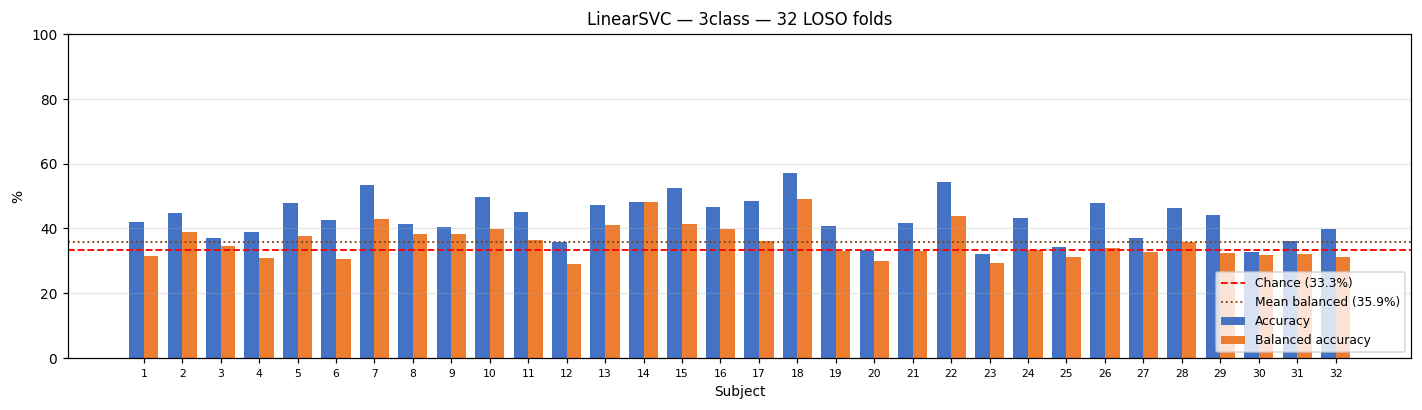

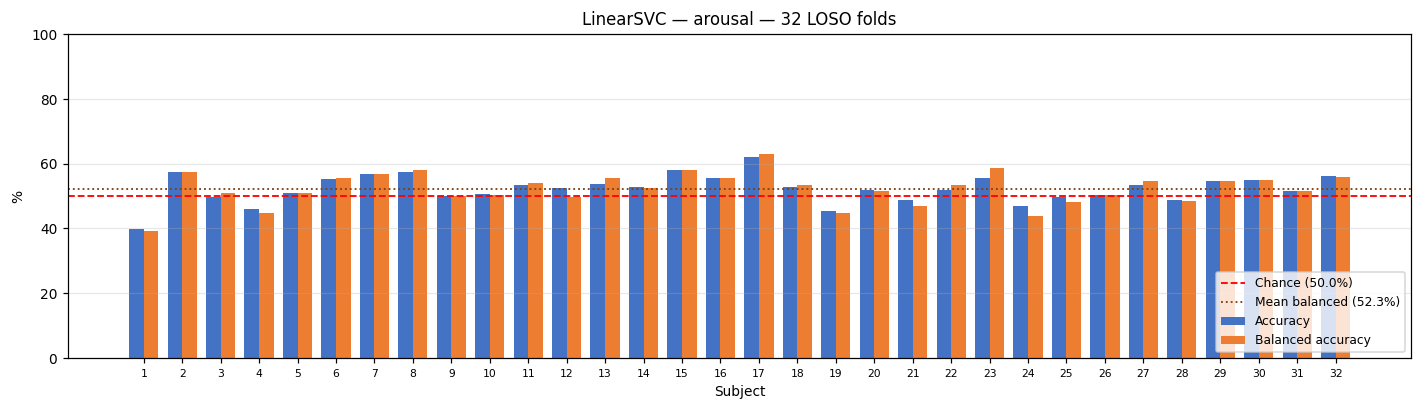

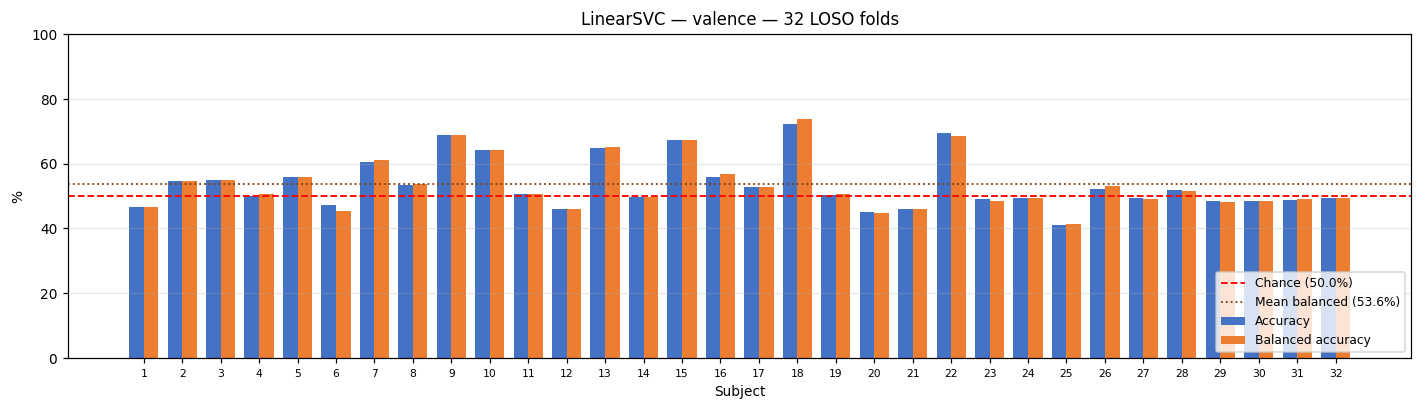

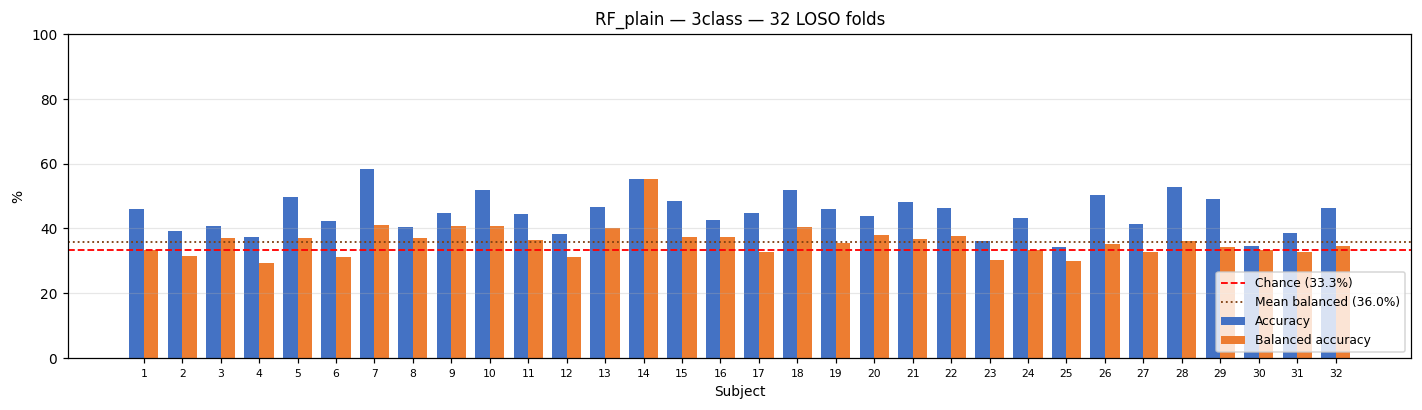

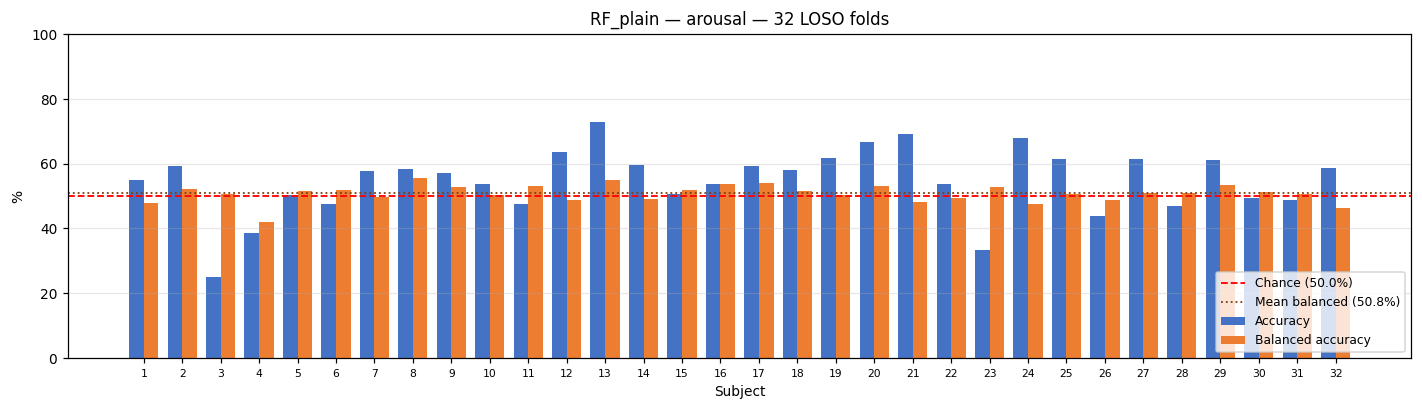

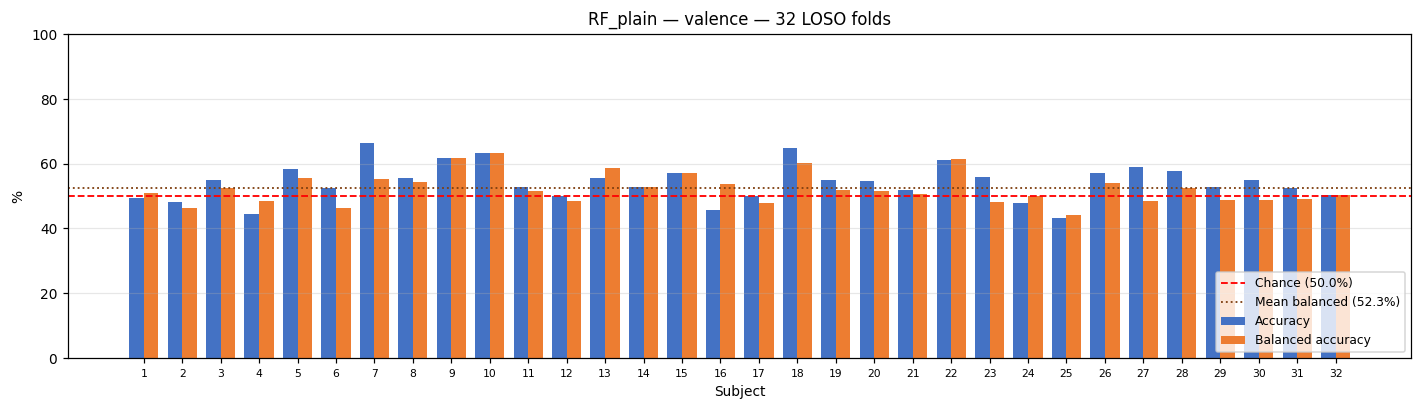

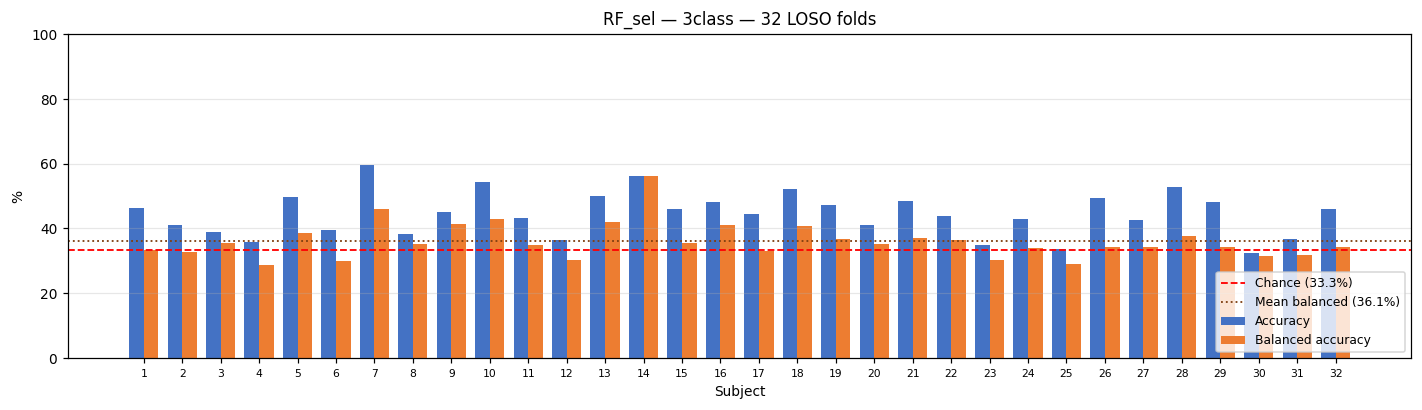

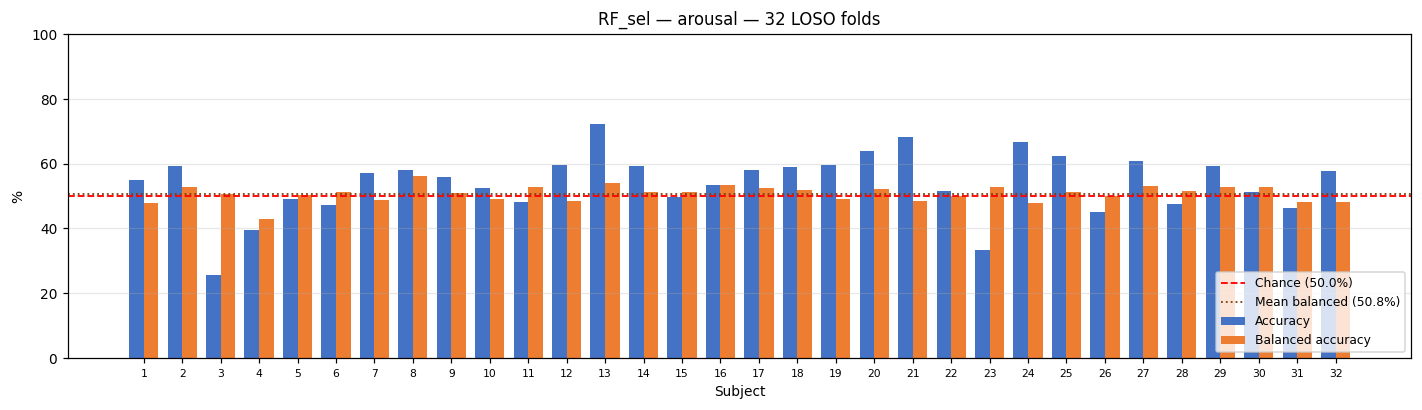

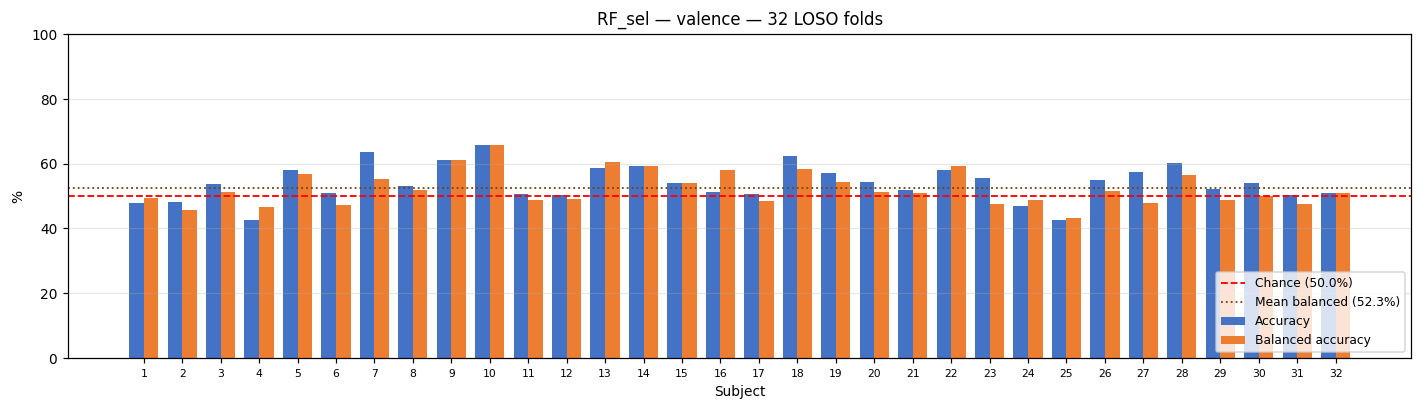

In [14]:
for (m, t), r in sorted(results.items()):
    sids = [f['sid'] for f in r['per_fold']]
    accs = [f['acc'] for f in r['per_fold']]
    bals = [f['bal_acc'] for f in r['per_fold']]

    fig, ax = plt.subplots(figsize=(13, 3.8))
    xp = np.arange(len(sids)); w = 0.38
    ax.bar(xp - w/2, accs, w, label='Accuracy', color='#4472C4')
    ax.bar(xp + w/2, bals, w, label='Balanced accuracy', color='#ED7D31')
    ax.axhline(r['chance'], color='red', ls='--', lw=1.2,
               label=f'Chance ({r["chance"]:.1f}%)')
    ax.axhline(r['bal_acc'], color='#7f3f10', ls=':', lw=1.2,
               label=f'Mean balanced ({r["bal_acc"]:.1f}%)')
    ax.set_xticks(xp); ax.set_xticklabels(sids, fontsize=7)
    ax.set_xlabel('Subject'); ax.set_ylabel('%')
    ax.set_title(f'{m} — {t} — 32 LOSO folds')
    ax.set_ylim(0, 100); ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

## Section 9 — Confusion matrices

Predictions pooled across all 32 folds, normalised by true-class row so each row sums to 100%. Raw counts in parentheses.

A row concentrated in one column indicates that class is being systematically misassigned. For the 3-class task the Neutral band (ratings 4.5–5.5) holds only 17% of segments and is the one most likely to be absorbed into its neighbours.

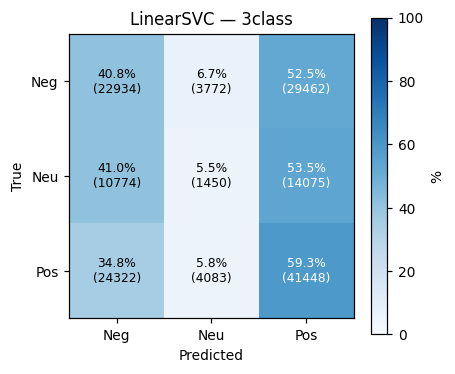

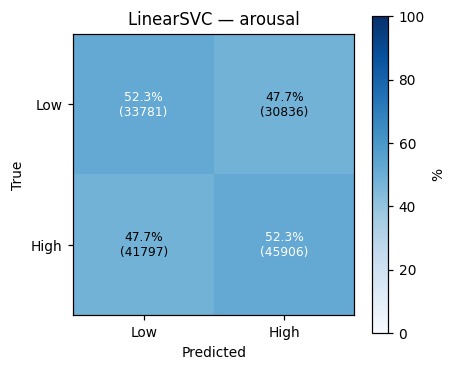

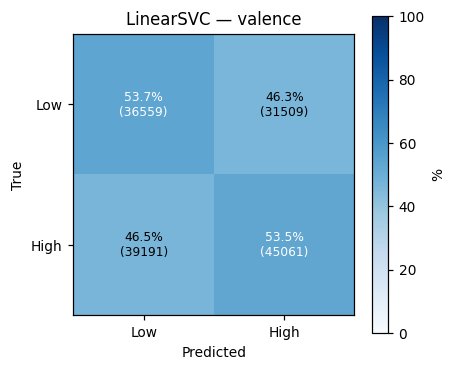

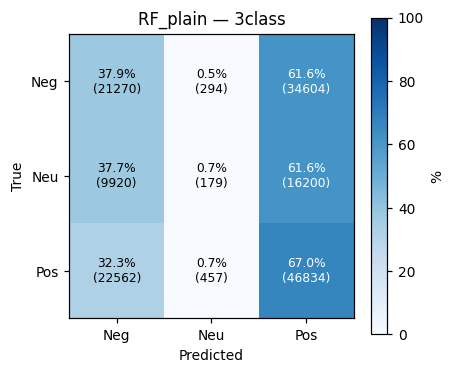

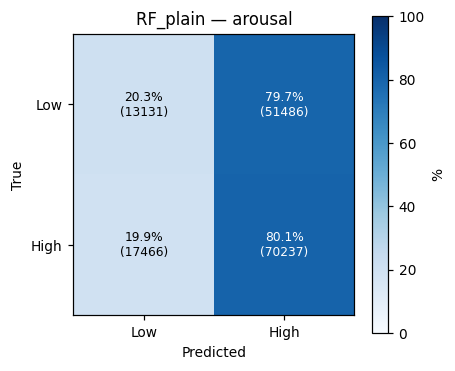

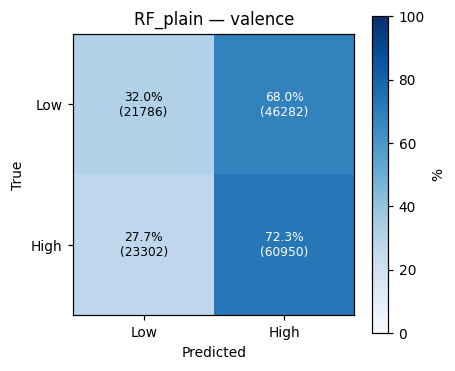

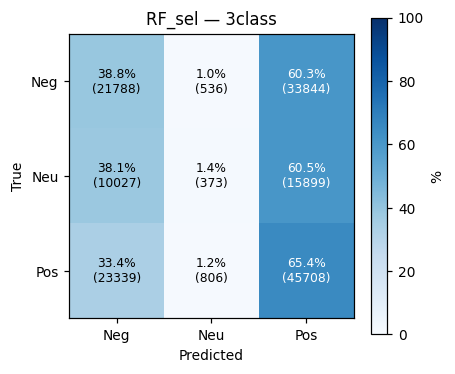

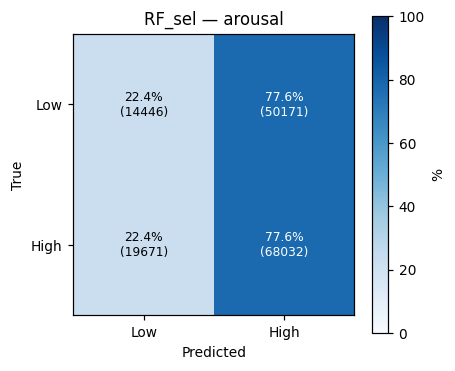

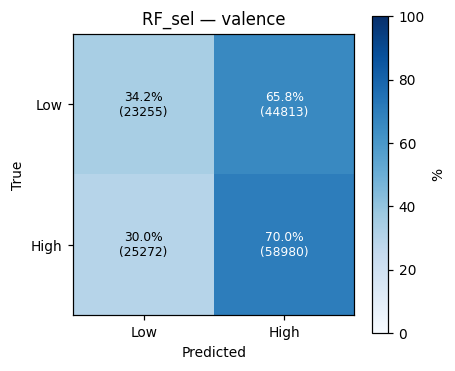

In [15]:
for (m, t), r in sorted(results.items()):
    y_true = np.concatenate([f['true'] for f in r['per_fold']])
    y_pred = np.concatenate([f['pred'] for f in r['per_fold']])
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    names = CLASS_NAMES[t]

    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names); ax.set_yticklabels(names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{m} — {t}')
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f'{cm_pct[i,j]:.1f}%\n({cm[i,j]})', ha='center', va='center',
                    color='white' if cm_pct[i,j] > 50 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax, label='%')
    plt.tight_layout(); plt.show()

## Section 10 — Comparison against published DEAP LOSO results

References are the matched-protocol figures from Table 2 of Report 2 Part 1 — DEAP, LOSO, 32 subjects. The subject-dependent figures in Table 1, which reach the mid-90s, are excluded because they train and test on the same person and are not comparable.

Every reference plotted uses deep learning with domain adaptation. This run is classical machine learning on handcrafted features with no adaptation, so it sits at the floor of that comparison by construction.

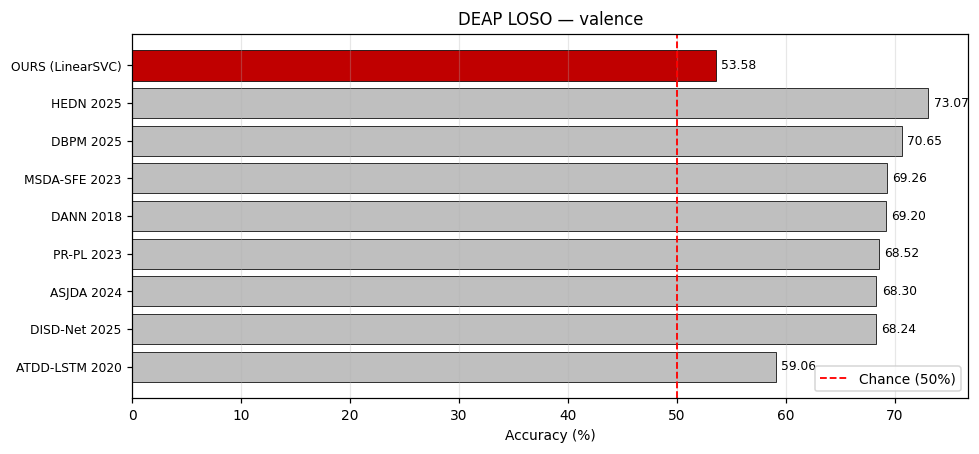

valence: ours acc=53.58% bal=53.61% (LinearSVC). All references use deep learning + domain adaptation.



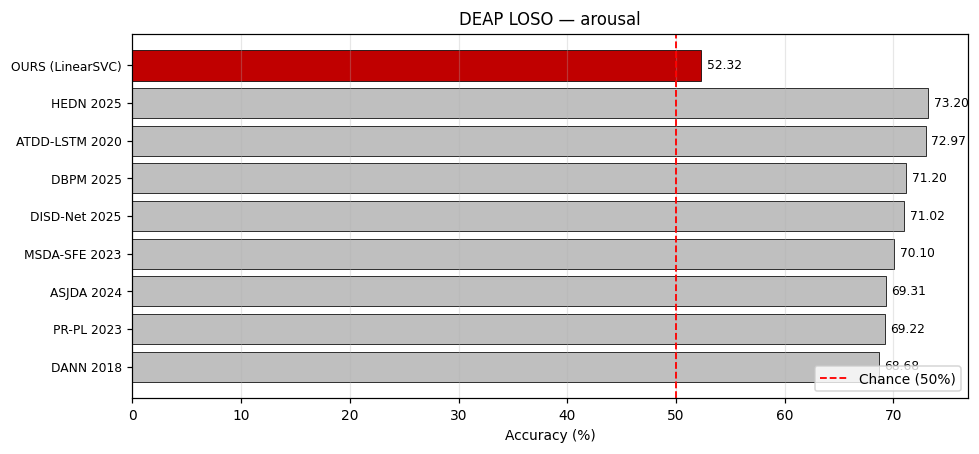

arousal: ours acc=52.32% bal=52.30% (LinearSVC). All references use deep learning + domain adaptation.



In [16]:
SOTA = {
    'valence': [('ATDD-LSTM 2020', 59.06), ('DISD-Net 2025', 68.24),
                ('ASJDA 2024', 68.30), ('PR-PL 2023', 68.52),
                ('DANN 2018', 69.20), ('MSDA-SFE 2023', 69.26),
                ('DBPM 2025', 70.65), ('HEDN 2025', 73.07)],
    'arousal': [('DANN 2018', 68.68), ('PR-PL 2023', 69.22),
                ('ASJDA 2024', 69.31), ('MSDA-SFE 2023', 70.10),
                ('DISD-Net 2025', 71.02), ('DBPM 2025', 71.20),
                ('ATDD-LSTM 2020', 72.97), ('HEDN 2025', 73.20)],
}

for task in ['valence', 'arousal']:
    ours = [(m, r['bal_acc'], r['acc']) for (m, t), r in results.items() if t == task]
    if not ours:
        continue
    best_m, best_bal, best_acc = max(ours, key=lambda x: x[1])

    fig, ax = plt.subplots(figsize=(9, 4.2))
    names = [n for n, _ in SOTA[task]] + [f'OURS ({best_m})']
    vals  = [v for _, v in SOTA[task]] + [best_acc]
    cols  = ['#BFBFBF'] * len(SOTA[task]) + ['#C00000']
    ax.barh(np.arange(len(names)), vals, color=cols, edgecolor='black', lw=0.5)
    ax.axvline(50, color='red', ls='--', lw=1.2, label='Chance (50%)')
    ax.set_yticks(np.arange(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('Accuracy (%)')
    ax.set_title(f'DEAP LOSO — {task}')
    ax.legend(loc='lower right'); ax.grid(True, axis='x', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(v + 0.5, i, f'{v:.2f}', va='center', fontsize=8)
    plt.tight_layout(); plt.show()

    print(f'{task}: ours acc={best_acc:.2f}% bal={best_bal:.2f}% ({best_m}). '
          f'All references use deep learning + domain adaptation.\n')

## Section 11 — Save summary

Writes a formatted text summary to Drive for direct transfer into the report, alongside the two CSVs written during Section 5. The notes block records the LinearSVC substitution, the provenance of the feature subset, and the reason balanced accuracy was added to the brief's metric list.

In [17]:
out = DATA_DIR / 'report2_part2_classical_FINAL.txt'
with open(out, 'w') as f:
    f.write('Report 2 Part 2 — Classical Baselines — FINAL\n')
    f.write('=' * 80 + '\n\n')
    f.write(f'Date:      {datetime.now().strftime("%Y-%m-%d %H:%M")}\n')
    f.write(f'Dataset:   DEAP, 32 subjects, 40 trials, threshold 5.0\n')
    f.write(f'Labels:    rebuilt from participant_ratings.xls\n')
    f.write(f'Protocol:  LOSO, {N_SUBJECTS} folds\n')
    f.write(f'Features:  {"+".join(FEATURES)} ({X.shape[1]} dims, per-subject z-scored)\n')
    f.write(f'Segments:  {X.shape[0]}\n\n')

    f.write('METRICS (macro)\n')
    f.write('-' * 80 + '\n')
    f.write(f'{"Model":11s} {"Task":9s} {"Acc":>14s} {"Balanced":>14s} '
            f'{"P":>6s} {"R":>6s} {"F1":>6s} {"p":>8s}\n')
    for (m, t), r in sorted(results.items()):
        f.write(f'{m:11s} {t:9s} '
                f'{r["acc"]:6.2f}±{r["acc_std"]:5.2f} '
                f'{r["bal_acc"]:6.2f}±{r["bal_acc_std"]:5.2f} '
                f'{r["prec_macro"]:6.2f} {r["rec_macro"]:6.2f} '
                f'{r["f1_macro"]:6.2f} {r["p_one_sided"]:8.4f}\n')

    f.write('\nSIGNIFICANCE vs chance (one-sample t-test, one-sided)\n')
    f.write('-' * 80 + '\n')
    for (m, t), r in sorted(results.items()):
        v = 'ABOVE CHANCE' if r['p_one_sided'] < 0.05 else 'not significant'
        f.write(f'{m:11s} {t:9s} bal={r["bal_acc"]:6.2f}  chance={r["chance"]:5.2f}  '
                f't={r["t_stat"]:6.2f}  p={r["p_one_sided"]:.4f}  {v}\n')

    f.write('\nPUBLISHED DEAP LOSO (deep + domain-adapted)\n')
    f.write('-' * 80 + '\n')
    f.write('  HEDN 2025      73.07 val / 73.20 aro\n')
    f.write('  DBPM 2025      70.65 val / 71.20 aro\n')
    f.write('  DANN 2018      69.20 val / 68.68 aro\n')
    f.write('  ATDD-LSTM 2020 59.06 val / 72.97 aro\n')

    f.write('\nNOTES\n')
    f.write('-' * 80 + '\n')
    f.write('  LinearSVC substituted for RBF-SVM (O(N^2)-O(N^3), >90 h estimated).\n')
    f.write('  DE+PSD subset selected by 10-config experiment (notebook 02b).\n')
    f.write('  Balanced accuracy added to brief metrics due to class imbalance.\n')

print(f'Saved: {out.name}\n')
print(open(out).read())
print(f'\nAlso: {LOG_PATH.name}, {FOLD_PATH.name} '
      f'({total_runs * N_SUBJECTS} fold rows)')

Saved: report2_part2_classical_FINAL.txt

Report 2 Part 2 — Classical Baselines — FINAL

Date:      2026-07-30 16:40
Dataset:   DEAP, 32 subjects, 40 trials, threshold 5.0
Labels:    rebuilt from participant_ratings.xls
Protocol:  LOSO, 32 folds
Features:  DE+PSD (320 dims, per-subject z-scored)
Segments:  152320

METRICS (macro)
--------------------------------------------------------------------------------
Model       Task                 Acc       Balanced      P      R     F1        p
LinearSVC   3class     43.22± 6.44  35.91± 5.22  34.51  35.41  33.17   0.0049
LinearSVC   arousal    52.32± 4.29  52.30± 4.94  52.18  52.30  50.60   0.0071
LinearSVC   valence    53.58± 7.82  53.61± 7.98  53.56  53.61  52.98   0.0086
RF_plain    3class     44.83± 5.82  35.98± 4.79  34.01  35.40  31.53   0.0022
RF_plain    arousal    54.73±10.01  50.81± 2.68  51.21  50.81  46.27   0.0505
RF_plain    valence    54.32± 5.53  52.35± 4.72  52.79  52.35  50.41   0.0047
RF_sel      3class     44.56± 6.59  3

## Section 12 — Next

`03_baselines_deep_colab.ipynb` covers the remaining three baselines — CNN, LSTM and BiLSTM on raw 32×128 segments — completing the manual-features versus end-to-end comparison the brief requires.

The classical section of Report 2 Part 2 draws on four outputs: the metric table (Section 6), the significance tests (Section 7), the label-correction record, and the feature ablation from notebook 02b.